<a href="https://colab.research.google.com/github/Sandyon1top/AI/blob/main/SandipDhakal_workshop5_CNN_Fruit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 5
## End-to-End CNN Model for Fruit Image Classification
### Amazon Fruits Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Setup: Download the Dataset

We use the **Fruits Classification** dataset from Kaggle (Amazon fruits: pupunha, guarana, graviola, tucuma, acai, cupuacu).

**Option A – Kaggle CLI (recommended if you have a kaggle.json key):**
```bash
pip install kaggle
kaggle datasets download -d fernandol/fruits-360-dataset-multiple-fruits
unzip fruits-360-dataset-multiple-fruits.zip
```

**Option B – Manual download:**  
Download the dataset from the link provided by your module leader and place it so the folder structure is:
```
data/
  train/
    pupunha/
    guarana/
    graviola/
    tucuma/
    acai/
    cupuacu/
  test/
    pupunha/
    ...
```

> Update the `train_dir` and `test_dir` paths in the cell below to match where you saved the data.

---
## Step 0 – Imports and Configuration

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

# ── Paths –
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/FruitinAmazon/test"

# Hyper-parameters
IMG_HEIGHT    = 128
IMG_WIDTH     = 128
BATCH_SIZE    = 32
VAL_SPLIT     = 0.2       # 80 % train / 20 % validation
TRAIN_EPOCHS  = 250
TRAIN_BATCH   = 16
SEED          = 123

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


---
## Task 1 – Data Understanding and Visualisation

### 1a. Visualise One Random Image Per Class

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


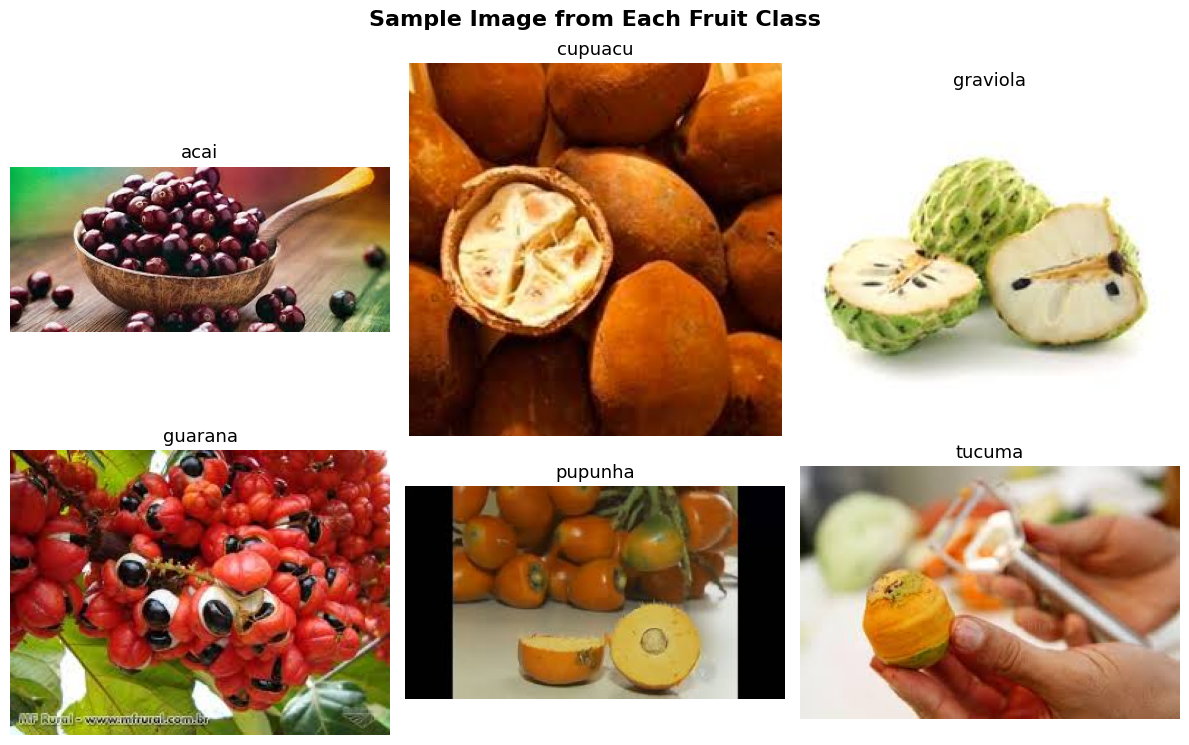

In [3]:
# ── 1a. Load and visualise one image per class ────────────────────────────────

# Get sorted list of class directories from the train folder
class_dirs = sorted(
    [d for d in os.listdir(train_dir)
     if os.path.isdir(os.path.join(train_dir, d))]
)
print(f"Classes found ({len(class_dirs)}):", class_dirs)

# Select one random image from each class
random_images = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    chosen   = random.choice(images)
    random_images.append((cls, os.path.join(cls_path, chosen)))

# Display in a grid with 2 rows
num_classes = len(random_images)
cols        = (num_classes + 1) // 2      # ceiling division → columns per row
rows        = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes      = axes.flatten()

for idx, (cls_name, img_path) in enumerate(random_images):
    img = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls_name, fontsize=13)
    axes[idx].axis("off")

# Hide any extra axes if num_classes is odd
for idx in range(num_classes, len(axes)):
    axes[idx].axis("off")

plt.suptitle("Sample Image from Each Fruit Class", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:**  
  
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, and cupuacu.  
- Images vary in size, colour, background, and lighting conditions.  
- Some classes (e.g. graviola) have distinctive shapes while others (e.g. pupunha vs tucuma) look visually similar, which may make classification harder.

### 1b. Check for Corrupted Images

In [4]:
# ── 1b. Detect and remove corrupted images

corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()          # verify that it is, in fact an image
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


---
## Task 2 – Loading and Pre-processing Image Data

In [5]:
# ── Task 2. Load & preprocess data using image_dataset_from_directory ─────────

# Rescaling layer: normalise pixel values from [0, 255] → [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset (80 %)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = True,
    validation_split = VAL_SPLIT,
    subset           = 'training',
    seed             = SEED
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ── Validation dataset (20 %)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = False,
    validation_split = VAL_SPLIT,
    subset           = 'validation',
    seed             = SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ── Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = False,
    seed          = SEED
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Retrieve class names inferred from sub-folder names
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else class_dirs
num_classes = len(class_names)
print("Class names :", class_names)
print("Num classes :", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


---
## Task 3 – Build the CNN Model

Architecture as specified in the worksheet:

| Block | Layer | Details |
|---|---|---|
| Conv Block 1 | Conv2D | 32 filters, 3×3, padding=same, stride=1, ReLU |
| | MaxPooling2D | 2×2, stride=2 |
| Conv Block 2 | Conv2D | 32 filters, 3×3, padding=same, stride=1, ReLU |
| | MaxPooling2D | 2×2, stride=2 |
| FCN | Flatten | — |
| | Dense | 128 neurons, ReLU |
| | Dense | 64 neurons, ReLU |
| | Dense (Output) | num_classes, Softmax |

In [6]:
# ── Task 3. Define CNN architecture
model = keras.Sequential([

    # ── Convolutional Block 1
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = (1, 1),
        activation  = 'relu',
        input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
        name        = 'conv2d_1'
    ),
    layers.MaxPooling2D(
        pool_size = (2, 2),
        strides   = (2, 2),
        name      = 'maxpool_1'
    ),

    # ── Convolutional Block 2
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = (1, 1),
        activation  = 'relu',
        name        = 'conv2d_2'
    ),
    layers.MaxPooling2D(
        pool_size = (2, 2),
        strides   = (2, 2),
        name      = 'maxpool_2'
    ),

    # ── Fully Connected Network
    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_128'),
    layers.Dense(64,  activation='relu', name='dense_64'),

    # Output layer – one neuron per class, softmax for probability distribution
    layers.Dense(num_classes, activation='softmax', name='output')
], name="CNN_Fruit_Classifier")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Fruit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 – Compile and Train the Model

In [7]:
# ── Task 4a. Compile

model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [8]:
# ── Task 4b. Callbacks

# Save the best model (highest val_accuracy) during training
checkpoint_cb = ModelCheckpoint(
    filepath          = 'best_model.h5',
    monitor           = 'val_accuracy',
    save_best_only    = True,
    verbose           = 1
)

# Stop early if validation loss has not improved for 20 consecutive epochs
early_stop_cb = EarlyStopping(
    monitor   = 'val_loss',
    patience  = 20,
    verbose   = 1,
    restore_best_weights = True
)

print("Callbacks configured.")

Callbacks configured.


In [9]:
# ── Task 4c. Train
# batch_size=16 and epochs=250 as specified in the worksheet

# Rebuild datasets with batch_size=16 for training as required
rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds_16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = TRAIN_BATCH,   # 16
    shuffle          = True,
    validation_split = VAL_SPLIT,
    subset           = 'training',
    seed             = SEED
).map(lambda x, y: (rescale(x), y))

val_ds_16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = TRAIN_BATCH,   # 16
    shuffle          = False,
    validation_split = VAL_SPLIT,
    subset           = 'validation',
    seed             = SEED
).map(lambda x, y: (rescale(x), y))

history = model.fit(
    train_ds_16,
    epochs          = TRAIN_EPOCHS,   # 250
    validation_data = val_ds_16,
    callbacks       = [checkpoint_cb, early_stop_cb]
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1788 - loss: 1.8633
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.2222 - loss: 1.8627 - val_accuracy: 0.0000e+00 - val_loss: 2.1612
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3740 - loss: 1.6297
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.4167 - loss: 1.5815 - val_accuracy: 0.1111 - val_loss: 1.5659
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4910 - loss: 1.2669
Epoch 3: val_accuracy improved from 0.11111 to 0.27778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.4861 - loss: 1.2085 - val_accuracy: 0.2778 - val_loss: 1.5634
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6309 - loss: 0.9115
Epoch 4: val_accuracy improved from 0.27778 to 0.88889, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.6806 - loss: 0.8911 - val_accuracy: 0.8889 - val_loss: 0.5932
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9372 - loss: 0.5091
Epoch 5: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.9306 - loss: 0.4972 - val_accuracy: 0.7222 - val_loss: 0.8255
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9590 - loss: 0.2890
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.9306 - loss: 0.3465 - val_accuracy: 0.8333 - val_loss: 0.4234
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9694 - loss: 0.1673
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.9306 - loss: 0.2326 - val_accuracy: 0.8333 - val_loss: 0.4968
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9840 - loss: 0.089

### Visualise Training History

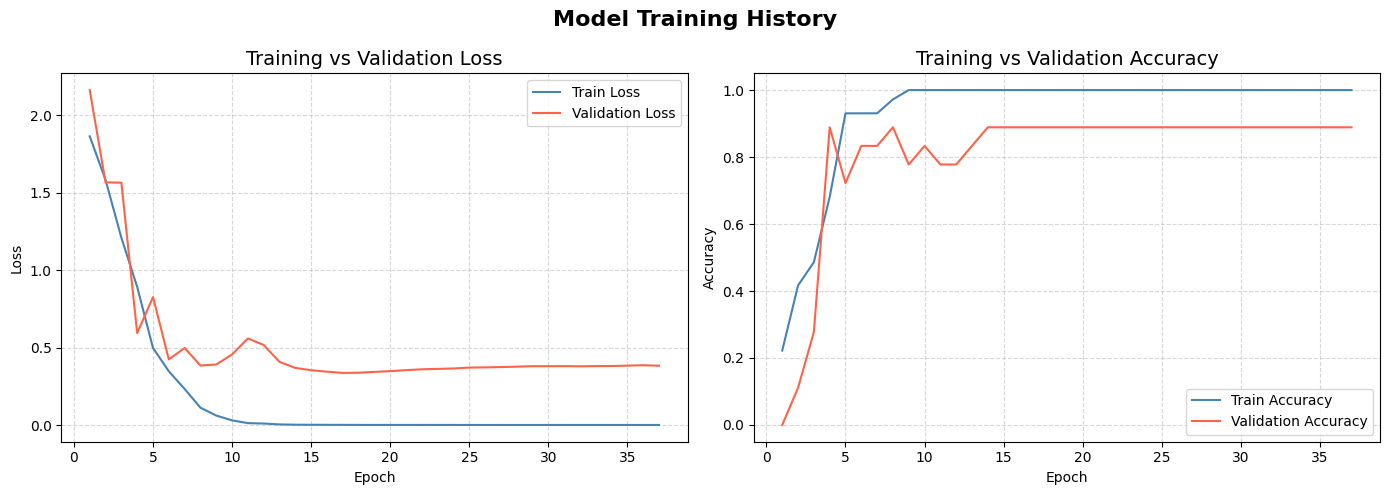

Plot saved as training_history.png


In [10]:
# ── Plot training & validation loss and accuracy ──────────────────────────────

epochs_ran = range(1, len(history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss
ax1.plot(epochs_ran, history.history['loss'],     label='Train Loss',      color='steelblue')
ax1.plot(epochs_ran, history.history['val_loss'], label='Validation Loss', color='tomato')
ax1.set_title('Training vs Validation Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ── Accuracy
ax2.plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
ax2.plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
ax2.set_title('Training vs Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Model Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as training_history.png")

---
## Task 5 – Evaluate the Model

In [11]:
# ── Task 5. Evaluate on the test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f} %)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.7000 - loss: 1.0494

Test Loss     : 1.0494
Test Accuracy : 0.7000 (70.00 %)


---
## Task 6 – Save and Load the Model

In [12]:
# ── Task 6a. Save the trained model
model.save('cnn_fruit_classifier.h5')
print("Model saved to: cnn_fruit_classifier.h5")

Model saved to: cnn_fruit_classifier.h5


In [13]:
# ── Task 6b. Load the saved model and re-evaluate
loaded_model = keras.models.load_model('cnn_fruit_classifier.h5')
print("Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model – Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model – Test Accuracy : {loaded_acc:.4f} ({loaded_acc * 100:.2f} %)")

Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7000 - loss: 1.0494

Loaded Model – Test Loss     : 1.0494
Loaded Model – Test Accuracy : 0.7000 (70.00 %)


---
## Task 7 – Predictions and Classification Report

In [14]:
# ── Task 7. Predictions and classification report
# Collect all true labels and predicted labels from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → integer class labels using argmax
y_pred = np.argmax(y_pred_probs, axis=1)

print("Sample Predictions (first 10):")
print("Predicted labels:", [class_names[p] for p in y_pred[:10]])
print("Actual    labels:", [class_names[t] for t in y_true[:10]])

Sample Predictions (first 10):
Predicted labels: ['acai', 'cupuacu', 'acai', 'acai', 'acai', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']
Actual    labels: ['acai', 'acai', 'acai', 'acai', 'acai', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']


In [15]:
# ── Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names = class_names
)
print("Classification Report")
print("=" * 60)
print(report)

Classification Report
              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.83      1.00      0.91         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.66        30
weighted avg       0.73      0.70      0.66        30



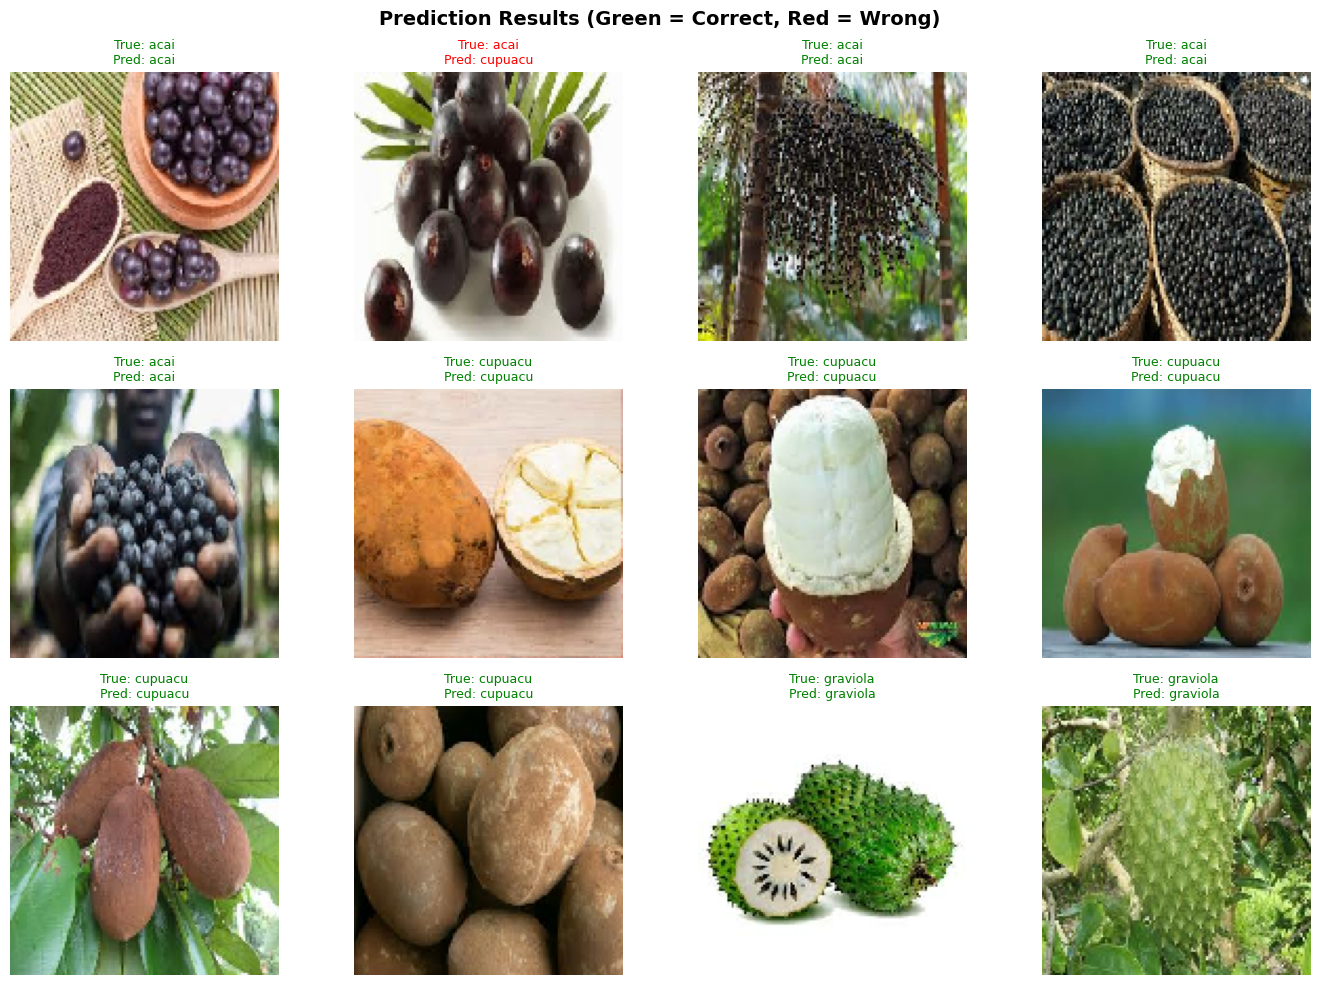

Prediction grid saved as predictions_grid.png


In [16]:
# ── (Bonus) Visualise a grid of predictions ───────────────────────────────────

# Grab a single batch of test images to display
sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images, verbose=0), axis=1)

n_show = min(12, len(sample_images))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(sample_images[i].numpy())
    true_label = class_names[int(sample_labels[i])]
    pred_label = class_names[sample_preds[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}",
                      fontsize=9, color=color)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('Prediction Results (Green = Correct, Red = Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction grid saved as predictions_grid.png")

---
## Summary of Deliverables

| Deliverable | Status |
|---|---|
| Code Implementation (build, train, evaluate, save, load) | ✅ |
| Visualisation – training/validation loss & accuracy graph | ✅ (`training_history.png`) |
| Classification Report on test data | ✅ |
| Saved model `.h5` file | ✅ (`cnn_fruit_classifier.h5` + `best_model.h5`) |

---
*6CS012 – Worksheet 5 | Artificial Intelligence and Machine Learning*